## This notebook trains the classical model on the PAWS dataset. The accuracy will be measured and stored for final performance comparisons

In [1]:
#Importing required packages
import os
import sys
import time
from pathlib import Path
from datetime import date

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

sys.path.append(os.path.abspath(".."))

from src.classical_models import (
    combine_sentences,
    create_tfidf_vectorizer,
    vectorize_data,
    train_logistic_regression,
    predict,
    save_classical_model
)

from src.evaluate import (
    evaluate_classifier,
    compute_confusion_matrix
)

from src.utils import log_experiment

# 1. PAWS

In [2]:
#Load the processed datasets
train = pd.read_csv(
    "../datasets/processed/classical/paws_train.csv"
)

validation = pd.read_csv(
    "../datasets/processed/classical/paws_validation.csv"
)

test = pd.read_csv(
    "../datasets/processed/classical/paws_test.csv"
)

In [3]:
#Overview
print("Training:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

display(train.head())

print("\nMissing Values")
display(train.isnull().sum())

print("\nLabel Distribution")
display(train["label"].value_counts())

Training: (49401, 4)
Validation: (8000, 4)
Test: (8000, 4)


,id,sentence1,sentence2,label
0,1,"in paris , in october 1560 , he secretly met t...","in october 1560 , he secretly met with the eng...",0
1,2,the nba season of 1975 -- 76 was the 30th seas...,the 1975 -- 76 season of the national basketba...,1
2,3,"there are also specific discussions , public p...","there are also public discussions , profile sp...",0
3,4,when comparable rates of flow can be maintaine...,the results are high when comparable flow rate...,1
4,5,it is the seat of zerendi district in akmola r...,it is the seat of the district of zerendi in a...,1



Missing Values


id           0
sentence1    0
sentence2    0
label        0
dtype: int64


Label Distribution


label
0    27572
1    21829
Name: count, dtype: int64

In [4]:
#Combine Sentence Pairs
def combine_sentences(df):
    return (
        df["sentence1"]
        + " [SEP] "
        + df["sentence2"]
    )

In [5]:
X_train = combine_sentences(train)
X_validation = combine_sentences(validation)
X_test = combine_sentences(test)

y_train = train["label"]
y_validation = validation["label"]
y_test = test["label"]

In [6]:
#Define the TF-IDF Vectorizer
vectorizer = create_tfidf_vectorizer()

In [7]:
(
    X_train_vector,
    X_validation_vector,
    X_test_vector
) = vectorize_data(
    vectorizer,
    X_train,
    X_validation,
    X_test
)

In [8]:
#Training a Logistic Regression model
start_time = time.perf_counter()

model = train_logistic_regression(
    X_train_vector,
    y_train
)

end_time = time.perf_counter()

training_time = end_time - start_time

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 0.6951 seconds


In [9]:
#Predictions
start_time = time.perf_counter()

predictions, probabilities = predict(
    model,
    X_validation_vector
)

end_time = time.perf_counter()

inference_time = end_time - start_time

print(f"Inference Time: {inference_time:.4f} seconds")

Inference Time: 0.0092 seconds


In [10]:
#Evaluation
metrics = evaluate_classifier(
    y_validation,
    predictions,
    probabilities
)

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.5565
Precision: 0.4977
Recall: 0.2741
F1: 0.3535
ROC-AUC: 0.5481


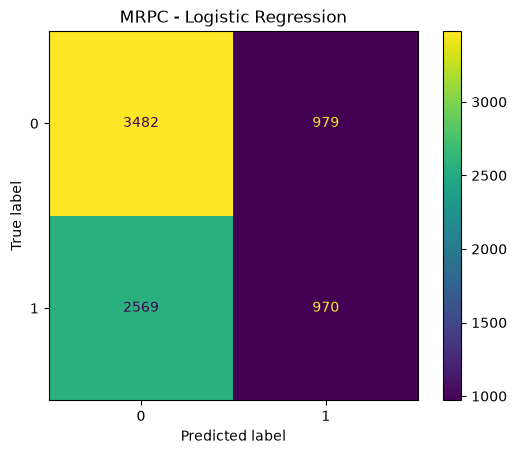

In [11]:
cm = compute_confusion_matrix(
    y_validation,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("MRPC - Logistic Regression")

plt.savefig(
    "../results/plots/paws_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

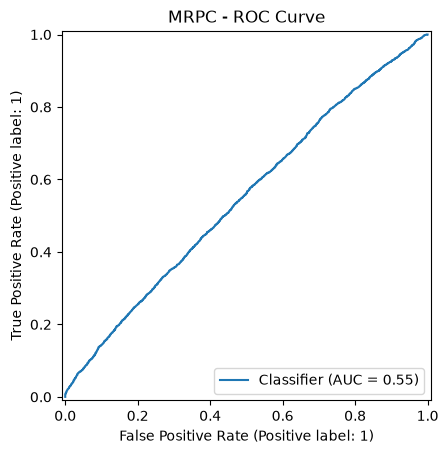

In [12]:
RocCurveDisplay.from_predictions(
    y_validation,
    probabilities
)

plt.title("MRPC - ROC Curve")

plt.savefig(
    "../results/plots/paws_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
#Saving the results
predictions_df = validation.copy()

predictions_df["prediction"] = predictions
predictions_df["probability"] = probabilities

predictions_df.to_csv(
    "../results/predictions/paws_predictions.csv",
    index=False
)

predictions_df.head()

,id,sentence1,sentence2,label,prediction,probability
0,1,bradd crellin represented barla cumbria on a t...,bradd crellin also represented barla great bri...,0,0,0.440196
1,2,they were there to enjoy us and they were ther...,they were there for us to enjoy and they were ...,1,0,0.447177
2,3,"after the end of the war in june 1902 , higgin...","in august , after the end of the war in june 1...",1,0,0.296577
3,4,from the merger of the four rivers council and...,shawnee trails council was formed from the mer...,1,1,0.525440
4,5,the group toured extensively and became famous...,the group toured extensively and was famous in...,1,0,0.427745


In [14]:
#Saving the predictions
metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv(
    "../results/metrics/paws_logreg_metrics.csv",
    index=False
)

metrics_df

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.5565,0.497691,0.274089,0.353499,0.548097


In [15]:
#Saving the model
Path("../models/classical").mkdir(
    parents=True,
    exist_ok=True
)

save_classical_model(
    model,
    vectorizer,
    "../models/classical/paws_logistic_regression.pkl",
    "../models/classical/paws_tfidf_vectorizer.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [16]:
#Error Analysis
errors = predictions_df[
    predictions_df["label"] != predictions_df["prediction"]
]

print(f"Incorrect Predictions: {len(errors)}")

errors.head(20)

Incorrect Predictions: 3548


,id,sentence1,sentence2,label,prediction,probability
1,2,they were there to enjoy us and they were ther...,they were there for us to enjoy and they were ...,1,0,0.447177
2,3,"after the end of the war in june 1902 , higgin...","in august , after the end of the war in june 1...",1,0,0.296577
4,5,the group toured extensively and became famous...,the group toured extensively and was famous in...,1,0,0.427745
5,6,kathy and her husband pete beale ( peter dean ...,kathy and her husband peter dean ( pete beale ...,1,0,0.472528
8,9,joe r. campa jr. is a former sailor of the uni...,joe r. campa jr. is a former u.s. navy matrose...,1,0,0.487618
15,16,a recording of folk songs done for the columbi...,a recording of folk songs made for the columbi...,1,0,0.409706
17,18,components of elastic potential systems store ...,components of elastic potential systems store ...,1,0,0.375419
18,19,earl st vincent was a british ship that was ca...,earl st vincent was a british ship that was ca...,1,0,0.382795
21,22,they are overlaid with sparse live orchestral ...,"they are overlaid with colourless , live playe...",0,1,0.520926
22,23,"in mathematical astronomy , his fame is due to...",his fame is due in mathematical astronomy to t...,1,0,0.331885


In [17]:
#Logging the output
experiment = {
    "Experiment ID": "EXP-003",
    "Date": date.today().isoformat(),
    "Phase": "Baseline",
    "Model": "Logistic Regression",
    "Dataset": "PAWS",
    "Train Split": len(train),
    "Validation Split": len(validation),
    "Test Split": len(test),
    "Batch Size": "N/A",
    "Learning Rate": "N/A",
    "Epochs": "N/A",
    "Accuracy": metrics["Accuracy"],
    "Precision": metrics["Precision"],
    "Recall": metrics["Recall"],
    "F1": metrics["F1"],
    "ROC-AUC": metrics["ROC-AUC"],
    "BLEU": "N/A",
    "ROUGE": "N/A",
    "BERTScore": "N/A",
    "Train Time": training_time,
    "Inference Time": inference_time,
    "Notes": "TF-IDF (1,2)-gram baseline",
    "Status": "Completed"
}

log_experiment(
    "../logs/experiments.xlsx",
    experiment
)

print("Experiment logged successfully.")

Experiment logged successfully.


In [18]:
#Summary
print("=" * 60)
print("PAWS BASELINE COMPLETE")
print("=" * 60)

print(f"Accuracy      : {metrics['Accuracy']:.4f}")
print(f"Precision     : {metrics['Precision']:.4f}")
print(f"Recall        : {metrics['Recall']:.4f}")
print(f"F1 Score      : {metrics['F1']:.4f}")
print(f"ROC-AUC       : {metrics['ROC-AUC']:.4f}")
print(f"Training Time : {training_time:.4f} sec")
print(f"Inference Time: {inference_time:.4f} sec")

print("\nArtifacts Generated:")
print("- Model")
print("- Vectorizer")
print("- Metrics CSV")
print("- Predictions CSV")
print("- Confusion Matrix")
print("- ROC Curve")
print("- Experiment Log")

PAWS BASELINE COMPLETE
Accuracy      : 0.5565
Precision     : 0.4977
Recall        : 0.2741
F1 Score      : 0.3535
ROC-AUC       : 0.5481
Training Time : 0.6951 sec
Inference Time: 0.0092 sec

Artifacts Generated:
- Model
- Vectorizer
- Metrics CSV
- Predictions CSV
- Confusion Matrix
- ROC Curve
- Experiment Log
